<a href="https://colab.research.google.com/github/202422/Startup-Operational-Status-prediction-using-Machine-learning/blob/work_branch/Modelling/Multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
df = pd.read_csv("company_feat_eng_df.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head(15)

,status,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,3,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-1.067472,-0.250311,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,1.942436,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,3,0,0.258618,0.049336,-0.392899,-0.291683,0.384564,-0.553941,-1.116427,-0.366961,-0.514252,-1.067472,0.012759,0.438643,-0.151095,0.618435,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,3,0,0.887539,-0.611010,-0.392899,-0.291683,0.384564,1.355647,1.773511,5.295752,0.138444,-0.488618,-0.542295,-0.696810,-0.151095,2.404255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,3,0,-0.581405,0.710249,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.542930,-0.412942,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
x = df.drop(["status","isClosed"], axis = 1)
y = df[["status"]]

In [6]:
x

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,-0.208669,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
44074,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,0.011392,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44075,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,-0.672770,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44076,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,-0.065070,-0.696810,-0.151095,3.533147,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Multiclass Classification
## A. Oversampling and spliting
## B. Training models
      1. AdaBoostClassifier
      2. GradientBoostingClassifier


## A. Oversampling and spliting


In [7]:
y.value_counts()

,count
status,
3,41393
0,1783
1,802
2,100


In [8]:
# Oversampling
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [9]:
y_resampled.value_counts()

,count
status,
0,41393
1,41393
2,41393
3,41393


In [10]:
x_resampled

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165567,-1.930032,1.483385,-0.392899,-0.291683,0.384564,1.992176,1.773511,0.648265,1.523031,0.114404,-2.868168,-0.696810,-0.151095,3.533147,0.0,0.594848,0.0,0.0,0.0,0.0,0.0,0.405152,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165568,-3.363791,2.090529,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.046079,-0.403765,-7.048264,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165569,-2.900135,1.912482,-0.392899,-1.225971,-0.961081,1.551775,1.273640,-0.366961,0.488721,-0.842382,-5.546456,-0.500411,0.377607,2.074441,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.691879,0.308121,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165570,-2.489662,1.740740,-0.392899,-0.291683,0.384564,0.070475,-0.393942,-0.366961,0.605153,2.600898,-4.336932,0.154780,-0.151095,-0.027763,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size = 0.2)

In [12]:
x_train

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
98499,0.085713,-4.064186,-0.392899,-0.291683,0.384564,1.768057,1.519128,-0.366961,-0.399346,-0.873640,-0.348448,-0.596864,-0.151095,2.952739,0.176047,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.823953,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,1.00000,0.000000
107985,0.182404,-5.654090,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-1.434174,-0.549632,-1.031632,0.154780,-0.151095,0.218221,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.363187,0.636813,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,1.00000,0.000000
51816,0.077011,-1.605059,-0.392899,-0.291683,0.384564,1.992176,1.773511,-0.366961,0.644714,0.768322,-0.148148,-0.696810,-0.151095,3.533147,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.0,0.0,0.067306,0.0,0.932694,0.000000,0.0000,0.0,0.0,0.00000,0.000000
88054,0.468363,-3.134037,-0.392899,-1.642047,-4.193133,-0.236695,-0.393942,-0.366961,-1.434174,0.807958,-1.467866,0.154780,1.647477,0.093244,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.501600,0.498400,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.5016,0.0,0.0,0.49840,0.000000
4023,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.669102,-0.208669,0.154780,-0.151095,0.218221,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,1.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111774,0.286756,-4.066774,-0.392899,-1.642047,-1.491159,-0.553941,-0.393942,-0.366961,-1.434174,-0.425767,-1.166171,0.154780,0.585875,0.218221,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,1.00000,0.000000
159293,-1.575047,1.303919,0.352765,-0.291683,0.774830,-0.094895,-0.393942,-0.366961,-0.043547,0.824841,-2.058492,-0.138969,0.385846,0.037383,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,0.72117,0.278830
71243,0.678003,-5.656367,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.097694,0.866048,-3.835034,-0.129084,-0.151095,0.236260,0.000000,0.000000,0.0,0.0,0.0,0.0,0.361788,0.000000,0.0,0.638212,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.361788,0.0000,0.0,0.0,0.00000,0.638212
131021,-0.265948,0.449131,1.673118,2.409044,0.360898,-0.553941,-0.755583,-0.366961,0.064592,-0.947227,-0.329628,-0.890947,0.335735,0.418549,0.000000,0.000000,0.0,0.0,0.0,0.0,0.500551,0.499449,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0000,0.0,0.0,1.00000,0.000000


In [13]:
y_train.value_counts()

,count
status,
3,33146
0,33140
2,33120
1,33051


In [14]:
y_test.value_counts()

,count
status,
1,8342
2,8273
0,8253
3,8247



## B. Training models
  1. **AdaBoostClassifier**
      

In [15]:
model_ada = AdaBoostClassifier()
paramgrid_ada = {
    'n_estimators': [200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=3)]
}
grid_ada = GridSearchCV(model_ada,paramgrid_ada, cv = 5)

In [16]:
grid_ada.fit(x_train,np.ravel(y_train))

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'estimator': [DecisionTreeClassifier(max_depth=3)],
                         'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [200]})

In [17]:
grid_ada.best_params_

{'estimator': DecisionTreeClassifier(max_depth=3),
 'learning_rate': 0.1,
 'n_estimators': 200}

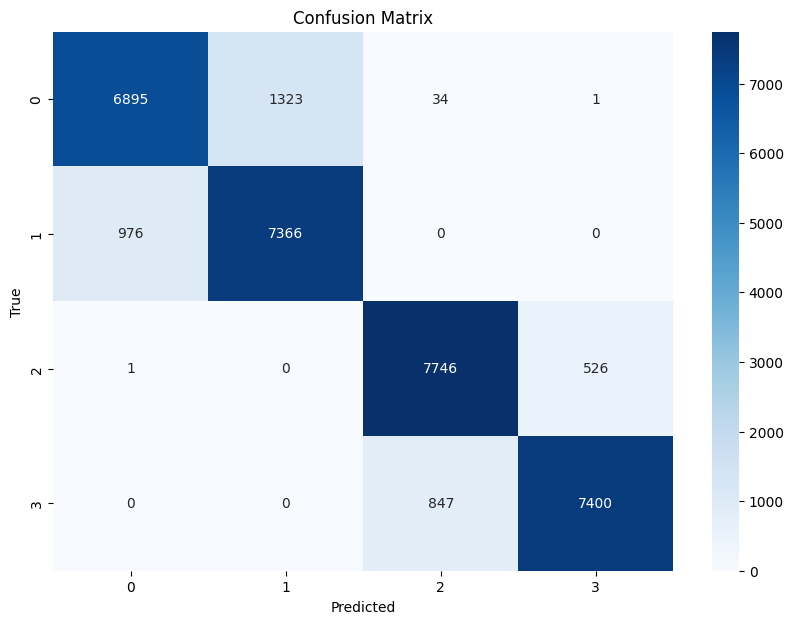

In [18]:
# Matrice de confusion
conf_matrix = confusion_matrix(y_test, grid_ada.best_estimator_.predict(x_test))
plt.figure(figsize = (10,7))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Blues", xticklabels = ["0","1","2","3"], yticklabels = ["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Rapport de classification
class_report = classification_report(y_test, grid_ada.best_estimator_.predict(x_test))
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      8253
           1       0.85      0.88      0.87      8342
           2       0.90      0.94      0.92      8273
           3       0.93      0.90      0.92      8247

    accuracy                           0.89     33115
   macro avg       0.89      0.89      0.89     33115
weighted avg       0.89      0.89      0.89     33115



In [20]:
joblib.dump(grid_ada.best_estimator_, "Ada_Boost_Multiclass.pkl")

['Ada_Boost_Multiclass.pkl']

2. **GradientBoostingClassifier**

In [ ]:
model_gd = GradientBoostingClassifier()
paramgrid_gd = {
    'n_estimators': [300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 7]
}
grid_gd = GridSearchCV(model_gd,paramgrid_gd, cv = 5)

In [ ]:
grid_gd.fit(x_train,np.ravel(y_train))

In [ ]:
grid_gd.best_params_

In [ ]:
# Matrice de confusion
conf_matrix_2 = confusion_matrix(y_test, grid_gd.best_estimator_.predict(x_test))
plt.figure(figsize = (10,7))
sns.heatmap(conf_matrix_2, annot = True, fmt = 'd', cmap = "Blues", xticklabels = ["0","1","2","3"], yticklabels = ["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Rapport de classification
class_report = classification_report(y_test, grid_gd.best_estimator_.predict(x_test))
print(class_report)